#### Fig. 1f

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os 
import scanpy as sc  
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as mpl 
import cell2location 
import pandas as pd
import seaborn as sns  
import pandas as pd  
import random
import math
pd.set_option('display.max_columns',400)
pd.set_option('display.max_categories',40)

# Set general parameters for publication-ready figures
plt.rcParams.update({
    'pdf.fonttype': 42,
    'font.family': 'Arial',  # Set font to Arial
    'font.size': 14,  # Set font size to at least 14
    'axes.labelsize': 14,  # Axes labels size
    'axes.titlesize': 16,  # Title size for axes
    'xtick.labelsize': 14,  # X-tick label size
    'ytick.labelsize': 14,  # Y-tick label size
    'legend.fontsize': 14,  # Legend font size
    'figure.titlesize': 16,  # Figure title size
    'lines.linewidth': 2,  # Line width for clarity
    'axes.linewidth': 1.5,  # Axis line width
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'text.color': 'black',  # Make sure text is black (not grey)
    'axes.labelcolor': 'black',  # Ensure axes labels are black
    'axes.edgecolor': 'black',  # Ensure edge of axes is black
    'xtick.color': 'black',  # Ensure X-tick marks are black
    'ytick.color': 'black',  # Ensure Y-tick marks are black
    'axes.titlepad': 20  # Padding for title
})



In [3]:
group_dict = {
    "Epithelial" : ["AT0", "AT1", "AT2", "Multiciliated (non-nasal)", "pre-TB secretory"],
    "Stroma" : ["Adventitial fibroblasts","Alveolar fibroblasts", "Myofibroblasts", "Peribronchial fibroblasts", "Pericytes",
                "Smooth muscle", "Smooth muscle FAM83D+", 
                "Subpleural fibroblasts"],
    "Immune" : ["Alveolar Mph CCL3+","Alveolar macrophages", "B cells", "CD4 T cells",
                "CD8 T cells", "Interstitial Mph perivascular", "Mast cells", "Monocyte-derived Mph", "NK cells", "Plasma cells", "T cells proliferating"],
    "Endothelial" : ["EC aerocyte capillary", "EC arterial", "EC general capillary", "EC venous pulmonary", 
                     "EC venous systemic", "Lymphatic EC differentiating", "Lymphatic EC mature"]

}

In [4]:
# group_dict = {
#     "Epithelial" : [ "AT1", "AT2", "Multiciliated (non-nasal)"],
#     "Stroma" : ["Adventitial fibroblasts","Alveolar fibroblasts", "Peribronchial fibroblasts", #"Pericytes",
#                 "Smooth muscle"],
#     "Immune" : ["Alveolar macrophages", "B cells", "CD4 T cells",
#                 "CD8 T cells", "Interstitial Mph perivascular",  "Plasma cells"],
#     "Endothelial" : ["EC aerocyte capillary",  "EC general capillary", "EC venous pulmonary", 
#                      "EC venous systemic"#, "Lymphatic EC differentiating"
#                      ]

# }

In [5]:
cell_type_order = [celltype for group in group_dict.values() for celltype in group]

In [6]:
save_dir = "f2_ann_finest_level"
# Create the directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

In [7]:
# load adata
adata_vis = sc.read_h5ad("/Users/jk/Documents/Lab2/visium/python_analysis/local_401/h5ad/adata_vis_assigned_cell_types_ann_finest_level.h5ad")

In [8]:
adata_vis

AnnData object with n_obs × n_vars = 160702 × 16959
    obs: 'in_tissue', 'array_row', 'array_col', 'library_id', 'alignment', 'desired_rc', 'actual_rc', 'xmin', 'xmax', 'ymin', 'ymax', 'hpx', 'vpx', 'slide', 'area', 'date', 'cytassist_ver', 'seq_batch', 'probe_date', 'probe_lot', 'probe_group', 'cond', 'cond_rep', 'rep', 'age ', 'sex', 'bmi', 'packyears', 'FVC', 'DLCO', '6MWD', 'outcome_long', 'tte_long', 'outcome_24m', 'tte_24m', 'lobe_lr', 'lobe', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'training_batch', 'AT0', 'AT1', 'AT2', 'AT2 proliferating', 'Adventitial fibroblasts', 'Alveolar Mph CCL3+', 'Alveolar Mph M

In [9]:
# Normalizing to median total counts
sc.pp.normalize_total(adata_vis,exclude_highly_expressed=True)
# Logarithmize the data
sc.pp.log1p(adata_vis)

# sc.pp.highly_variable_genes(adata_vis)
#sc.pp.scale(adata_vis)
# sc.tl.pca(adata_vis)

In [10]:
adata_vis.var_names

Index(['SAMD11', 'NOC2L', 'KLHL17', 'PLEKHN1', 'PERM1', 'HES4', 'ISG15',
       'AGRN', 'RNF223', 'C1orf159',
       ...
       'MT-CO1', 'MT-CO2', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4',
       'MT-ND5', 'MT-ND6', 'MT-CYB'],
      dtype='object', length=16959)

In [11]:
# df  = adata_vis.obs[ct_order]
df = adata_vis.obs[cell_type_order]

In [12]:
df

,AT0,AT1,AT2,Multiciliated (non-nasal),pre-TB secretory,Adventitial fibroblasts,Alveolar fibroblasts,Myofibroblasts,Peribronchial fibroblasts,Pericytes,Smooth muscle,Smooth muscle FAM83D+,Subpleural fibroblasts,Alveolar Mph CCL3+,Alveolar macrophages,B cells,CD4 T cells,CD8 T cells,Interstitial Mph perivascular,Mast cells,Monocyte-derived Mph,NK cells,Plasma cells,T cells proliferating,EC aerocyte capillary,EC arterial,EC general capillary,EC venous pulmonary,EC venous systemic,Lymphatic EC differentiating,Lymphatic EC mature
AACACGTGCATCGCAC-1-18_57617_A1,0.000967,0.000081,0.000023,0.000907,0.000324,0.234594,0.387183,0.003966,0.037726,0.014092,0.038652,0.060598,0.231837,0.009023,0.001108,3.730742,0.065855,0.019768,0.058909,0.003847,0.017594,0.016523,0.968134,0.044583,0.001719,0.002331,0.000529,0.001759,0.004936,0.003101,0.008538
AACACTTGGCAAGGAA-1-18_57617_A1,0.137828,0.802715,0.341800,0.598156,0.379554,0.139944,0.888112,0.124178,0.055564,0.479931,0.244876,0.049037,0.007688,0.039461,0.481472,0.039227,0.056936,0.042788,0.056085,0.030853,0.017642,0.036192,0.034395,0.089888,1.365678,0.136504,0.618607,0.156473,0.098999,0.080588,0.040189
AACAGGATTCATAGTT-1-18_57617_A1,0.005170,0.059832,0.082329,0.001180,0.000472,0.001260,0.068402,0.004225,0.071425,0.144042,0.011212,0.009665,0.028604,0.013375,0.020841,0.011103,0.079482,0.039857,0.008660,0.070889,0.006695,0.024105,0.012755,0.021346,1.006702,0.058915,2.460315,0.390035,0.384114,0.010103,0.009291
AACAGGTTCACCGAAG-1-18_57617_A1,0.001563,0.020343,0.057659,0.003326,0.000468,0.005092,0.061047,0.003756,0.015874,0.085721,0.029759,0.001750,0.015225,0.002046,0.002963,0.117381,0.077575,0.054498,0.016640,0.012171,0.010399,0.046806,0.021336,0.085016,0.162310,0.051763,2.538344,0.109793,0.134852,0.062362,0.013975
AACAGTCAGGCTCCGC-1-18_57617_A1,0.571262,0.794535,0.611508,0.006172,0.018862,0.012665,0.026405,0.104371,0.826019,0.035608,0.064397,0.001486,0.004463,0.101478,0.450508,0.019763,0.043126,0.032375,0.345387,0.003842,1.927120,0.041883,0.000658,0.004771,0.064305,0.007815,0.053782,0.002625,0.002509,0.015813,0.003935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTTCATTGGTCCAAG-1-22_16220_B1,0.367223,2.524808,4.255534,0.001477,0.013980,0.003124,1.719185,0.592959,0.352980,1.715962,0.010457,0.007975,0.049609,0.119464,0.480502,0.182870,0.994454,0.724625,0.810489,0.113724,0.055765,0.413240,0.041914,0.487826,3.753310,0.227036,2.941121,0.053537,0.037008,0.329601,0.037099
TGTTGCGTCCAAGATT-1-22_16220_B1,0.042970,3.252706,0.800204,0.003729,0.009157,0.015209,0.638489,0.041719,0.424080,0.238952,0.004884,0.017080,0.007916,0.153775,0.195006,0.057860,0.098929,0.061988,0.257543,0.071730,0.032344,0.028020,0.216965,0.119467,0.166659,0.043957,0.215042,0.018193,0.079329,0.029917,0.013606
TGTTGGAAGCTCGGTA-1-22_16220_B1,0.027733,0.414859,0.910561,0.002140,0.009947,0.005666,0.121399,0.007015,0.383614,0.056468,0.003175,0.000582,0.104944,0.042518,0.098804,0.119536,0.339794,0.091603,0.231813,0.005285,1.020134,0.110815,0.404067,0.132177,0.168115,0.014023,0.136537,0.006779,0.053962,0.016836,0.003369
TGTTGGATGGACTTCT-1-22_16220_B1,0.072429,0.449036,2.438682,0.013447,0.023343,0.017653,0.128469,0.033981,0.095104,0.053645,0.004464,0.001540,0.007772,0.100401,0.225288,0.050948,0.082476,0.062304,0.029476,0.016918,0.161680,0.072806,0.149471,0.043325,0.178297,0.031913,0.181172,0.010522,0.009545,0.012411,0.017603


In [13]:
df_norm = df.div(df.sum(axis=1), axis=0) 

In [14]:
df_norm

,AT0,AT1,AT2,Multiciliated (non-nasal),pre-TB secretory,Adventitial fibroblasts,Alveolar fibroblasts,Myofibroblasts,Peribronchial fibroblasts,Pericytes,Smooth muscle,Smooth muscle FAM83D+,Subpleural fibroblasts,Alveolar Mph CCL3+,Alveolar macrophages,B cells,CD4 T cells,CD8 T cells,Interstitial Mph perivascular,Mast cells,Monocyte-derived Mph,NK cells,Plasma cells,T cells proliferating,EC aerocyte capillary,EC arterial,EC general capillary,EC venous pulmonary,EC venous systemic,Lymphatic EC differentiating,Lymphatic EC mature
AACACGTGCATCGCAC-1-18_57617_A1,0.000162,0.000014,0.000004,0.000152,0.000054,0.039296,0.064855,0.000664,0.006319,0.002361,0.006474,0.010150,0.038834,0.001511,0.000186,0.624920,0.011031,0.003311,0.009868,0.000644,0.002947,0.002768,0.162168,0.007468,0.000288,0.000391,0.000089,0.000295,0.000827,0.000519,0.001430
AACACTTGGCAAGGAA-1-18_57617_A1,0.017967,0.104638,0.044555,0.077973,0.049477,0.018242,0.115770,0.016187,0.007243,0.062561,0.031921,0.006392,0.001002,0.005144,0.062762,0.005113,0.007422,0.005578,0.007311,0.004022,0.002300,0.004718,0.004484,0.011717,0.178023,0.017794,0.080638,0.020397,0.012905,0.010505,0.005239
AACAGGATTCATAGTT-1-18_57617_A1,0.001010,0.011694,0.016091,0.000231,0.000092,0.000246,0.013369,0.000826,0.013960,0.028153,0.002191,0.001889,0.005591,0.002614,0.004073,0.002170,0.015535,0.007790,0.001693,0.013855,0.001309,0.004711,0.002493,0.004172,0.196760,0.011515,0.480868,0.076232,0.075075,0.001975,0.001816
AACAGGTTCACCGAAG-1-18_57617_A1,0.000409,0.005323,0.015087,0.000870,0.000123,0.001332,0.015973,0.000983,0.004153,0.022429,0.007787,0.000458,0.003984,0.000535,0.000775,0.030713,0.020298,0.014260,0.004354,0.003185,0.002721,0.012247,0.005583,0.022245,0.042469,0.013544,0.664172,0.028728,0.035285,0.016317,0.003657
AACAGTCAGGCTCCGC-1-18_57617_A1,0.092147,0.128162,0.098639,0.000996,0.003043,0.002043,0.004259,0.016836,0.133241,0.005744,0.010388,0.000240,0.000720,0.016369,0.072669,0.003188,0.006956,0.005222,0.055713,0.000620,0.310854,0.006756,0.000106,0.000770,0.010373,0.001261,0.008675,0.000423,0.000405,0.002551,0.000635
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTTCATTGGTCCAAG-1-22_16220_B1,0.015681,0.107811,0.181714,0.000063,0.000597,0.000133,0.073410,0.025320,0.015072,0.073273,0.000447,0.000341,0.002118,0.005101,0.020518,0.007809,0.042464,0.030942,0.034608,0.004856,0.002381,0.017646,0.001790,0.020830,0.160269,0.009695,0.125588,0.002286,0.001580,0.014074,0.001584
TGTTGCGTCCAAGATT-1-22_16220_B1,0.005840,0.442098,0.108761,0.000507,0.001245,0.002067,0.086782,0.005670,0.057640,0.032478,0.000664,0.002321,0.001076,0.020901,0.026505,0.007864,0.013446,0.008425,0.035005,0.009749,0.004396,0.003808,0.029489,0.016238,0.022652,0.005975,0.029228,0.002473,0.010782,0.004066,0.001849
TGTTGGAAGCTCGGTA-1-22_16220_B1,0.005498,0.082244,0.180514,0.000424,0.001972,0.001123,0.024067,0.001391,0.076049,0.011194,0.000630,0.000115,0.020805,0.008429,0.019587,0.023697,0.067362,0.018160,0.045956,0.001048,0.202236,0.021968,0.080104,0.026203,0.033328,0.002780,0.027068,0.001344,0.010698,0.003338,0.000668
TGTTGGATGGACTTCT-1-22_16220_B1,0.015165,0.094017,0.510599,0.002815,0.004887,0.003696,0.026898,0.007115,0.019912,0.011232,0.000935,0.000322,0.001627,0.021022,0.047170,0.010667,0.017268,0.013045,0.006172,0.003542,0.033852,0.015244,0.031295,0.009071,0.037331,0.006682,0.037933,0.002203,0.001999,0.002598,0.003686


In [15]:
df_norm_cat = pd.concat([df_norm, adata_vis.obs[['library_id','cell_type_assigned']]], axis=1)

In [16]:
df_norm_cat

,AT0,AT1,AT2,Multiciliated (non-nasal),pre-TB secretory,Adventitial fibroblasts,Alveolar fibroblasts,Myofibroblasts,Peribronchial fibroblasts,Pericytes,Smooth muscle,Smooth muscle FAM83D+,Subpleural fibroblasts,Alveolar Mph CCL3+,Alveolar macrophages,B cells,CD4 T cells,CD8 T cells,Interstitial Mph perivascular,Mast cells,Monocyte-derived Mph,NK cells,Plasma cells,T cells proliferating,EC aerocyte capillary,EC arterial,EC general capillary,EC venous pulmonary,EC venous systemic,Lymphatic EC differentiating,Lymphatic EC mature,library_id,cell_type_assigned
AACACGTGCATCGCAC-1-18_57617_A1,0.000162,0.000014,0.000004,0.000152,0.000054,0.039296,0.064855,0.000664,0.006319,0.002361,0.006474,0.010150,0.038834,0.001511,0.000186,0.624920,0.011031,0.003311,0.009868,0.000644,0.002947,0.002768,0.162168,0.007468,0.000288,0.000391,0.000089,0.000295,0.000827,0.000519,0.001430,18_57617_A1,B cells
AACACTTGGCAAGGAA-1-18_57617_A1,0.017967,0.104638,0.044555,0.077973,0.049477,0.018242,0.115770,0.016187,0.007243,0.062561,0.031921,0.006392,0.001002,0.005144,0.062762,0.005113,0.007422,0.005578,0.007311,0.004022,0.002300,0.004718,0.004484,0.011717,0.178023,0.017794,0.080638,0.020397,0.012905,0.010505,0.005239,18_57617_A1,EC aerocyte capillary
AACAGGATTCATAGTT-1-18_57617_A1,0.001010,0.011694,0.016091,0.000231,0.000092,0.000246,0.013369,0.000826,0.013960,0.028153,0.002191,0.001889,0.005591,0.002614,0.004073,0.002170,0.015535,0.007790,0.001693,0.013855,0.001309,0.004711,0.002493,0.004172,0.196760,0.011515,0.480868,0.076232,0.075075,0.001975,0.001816,18_57617_A1,EC general capillary
AACAGGTTCACCGAAG-1-18_57617_A1,0.000409,0.005323,0.015087,0.000870,0.000123,0.001332,0.015973,0.000983,0.004153,0.022429,0.007787,0.000458,0.003984,0.000535,0.000775,0.030713,0.020298,0.014260,0.004354,0.003185,0.002721,0.012247,0.005583,0.022245,0.042469,0.013544,0.664172,0.028728,0.035285,0.016317,0.003657,18_57617_A1,EC general capillary
AACAGTCAGGCTCCGC-1-18_57617_A1,0.092147,0.128162,0.098639,0.000996,0.003043,0.002043,0.004259,0.016836,0.133241,0.005744,0.010388,0.000240,0.000720,0.016369,0.072669,0.003188,0.006956,0.005222,0.055713,0.000620,0.310854,0.006756,0.000106,0.000770,0.010373,0.001261,0.008675,0.000423,0.000405,0.002551,0.000635,18_57617_A1,Monocyte-derived Mph
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTTCATTGGTCCAAG-1-22_16220_B1,0.015681,0.107811,0.181714,0.000063,0.000597,0.000133,0.073410,0.025320,0.015072,0.073273,0.000447,0.000341,0.002118,0.005101,0.020518,0.007809,0.042464,0.030942,0.034608,0.004856,0.002381,0.017646,0.001790,0.020830,0.160269,0.009695,0.125588,0.002286,0.001580,0.014074,0.001584,22_16220_B1,AT2
TGTTGCGTCCAAGATT-1-22_16220_B1,0.005840,0.442098,0.108761,0.000507,0.001245,0.002067,0.086782,0.005670,0.057640,0.032478,0.000664,0.002321,0.001076,0.020901,0.026505,0.007864,0.013446,0.008425,0.035005,0.009749,0.004396,0.003808,0.029489,0.016238,0.022652,0.005975,0.029228,0.002473,0.010782,0.004066,0.001849,22_16220_B1,AT1
TGTTGGAAGCTCGGTA-1-22_16220_B1,0.005498,0.082244,0.180514,0.000424,0.001972,0.001123,0.024067,0.001391,0.076049,0.011194,0.000630,0.000115,0.020805,0.008429,0.019587,0.023697,0.067362,0.018160,0.045956,0.001048,0.202236,0.021968,0.080104,0.026203,0.033328,0.002780,0.027068,0.001344,0.010698,0.003338,0.000668,22_16220_B1,Monocyte-derived Mph
TGTTGGATGGACTTCT-1-22_16220_B1,0.015165,0.094017,0.510599,0.002815,0.004887,0.003696,0.026898,0.007115,0.019912,0.011232,0.000935,0.000322,0.001627,0.021022,0.047170,0.010667,0.017268,0.013045,0.006172,0.003542,0.033852,0.015244,0.031295,0.009071,0.037331,0.006682,0.037933,0.002203,0.001999,0.002598,0.003686,22_16220_B1,AT2


In [17]:

# Load the data

# Set threshold
threshold = 0.3 

# Get unique cell types from the 'cell_type_proportion' column
cell_types = df_norm_cat['cell_type_assigned'].unique()

# Initialize a set to store all passing indices
passing_indices = set()

# Loop over each cell type and collect indices that pass the threshold
for ct in cell_types:
    if ct in df_norm_cat.columns:
        idx = df_norm_cat.index
        passing_indices.update(idx)
    else:
        print(f"Skipping '{ct}' – not found as a column.")

# Final list of unique indices
filtered_indices = sorted(passing_indices)

# Subset anndata
adata_filtered = adata_vis[filtered_indices].copy()
    
# Order or restrict cell types shown on dotplot
adata_filtered = adata_filtered[adata_filtered.obs['cell_type_assigned'].isin(cell_type_order)].copy()



Skipping 'Multiciliated (nasal)' – not found as a column.
Skipping 'Club (nasal)' – not found as a column.
Skipping 'SMG duct' – not found as a column.
Skipping 'Migratory DCs' – not found as a column.
Skipping 'SM activated stress response' – not found as a column.
Skipping 'Classical monocytes' – not found as a column.
Skipping 'Non-classical monocytes' – not found as a column.
Skipping 'Basal resting' – not found as a column.
Skipping 'Hillock-like' – not found as a column.
Skipping 'Goblet (subsegmental)' – not found as a column.
Skipping 'Alveolar Mph proliferating' – not found as a column.
Skipping 'DC1' – not found as a column.
Skipping 'Suprabasal' – not found as a column.
Skipping 'Club (non-nasal)' – not found as a column.
Skipping 'Alveolar Mph MT-positive' – not found as a column.
Skipping 'Mesothelium' – not found as a column.
Skipping 'Plasmacytoid DCs' – not found as a column.
Skipping 'Deuterosomal' – not found as a column.
Skipping 'AT2 proliferating' – not found as a 

In [18]:
adata_filtered

AnnData object with n_obs × n_vars = 152941 × 16959
    obs: 'in_tissue', 'array_row', 'array_col', 'library_id', 'alignment', 'desired_rc', 'actual_rc', 'xmin', 'xmax', 'ymin', 'ymax', 'hpx', 'vpx', 'slide', 'area', 'date', 'cytassist_ver', 'seq_batch', 'probe_date', 'probe_lot', 'probe_group', 'cond', 'cond_rep', 'rep', 'age ', 'sex', 'bmi', 'packyears', 'FVC', 'DLCO', '6MWD', 'outcome_long', 'tte_long', 'outcome_24m', 'tte_24m', 'lobe_lr', 'lobe', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'training_batch', 'AT0', 'AT1', 'AT2', 'AT2 proliferating', 'Adventitial fibroblasts', 'Alveolar Mph CCL3+', 'Alveolar Mph M

In [19]:
markers = [
    # Epithelial
    "FXYD3", "EPCAM","ELF3",
    "IGFBP2", #"SERPINF1", "TSPAN1",
    "HOPX", "SFTA2",
    #"SFTPB", # AT0
    "CLIC5",# "SPOCK2", "TIMP3", # AT1
    #"MFSD2A", #"C11orf96", # AT2
    "RSPH1", "C20orf85", "C9orf24", # Multiciliated non nasal



    # Stroma
    "COL1A2","DCN","MFAP4",
    #"LUM","COL6A3","CFD",
    #"MFAP5", 
    "COL6A2",
    "SCARA5", 
    #"PI16", # Adventitial fib
    #"SPINT2", 
    #"LIMCH1", #"FGFR4", # Alveolar fib
    "LMOD1", #"ATP1B1", "TYRP1", # Myofibroblast
    #"COL15A1", "CXCL14", "DIO2", # Peribronchial fib
    "MYH11", #"TINAGL1", "PLN", # Smooth muscle


    # Immune
    "CD53",#"PTPRC",
    "CORO1A",
    #"CCL20",
    #"FAM89A", # Alveolar Mph
    "MS4A1", # B cells
    "ISG20", "CCL5", # Lymphoid
    "F13A1",# "FOLR2", # Interstitial Mph perivascular
    #"MS4A2", #"SLC18A2", # Mast
    #"TNFRSF17", # Plasma





    # Endo
    "CLDN5", "ECSCR", #"CLEC14A",# "AQP1", "RNASE1",
    "SOSTDC1", # EC aerocyte capillary
    #"IL7R", 
    "FCN3",# "MT1M", # EC general capillary
    "CPE", #"C7",
    "MMRN1", # EC venous pulmonary
    #"TPD52L1", "ZNF385D", # EC venous systemic
    


]

In [20]:
# ct_order = [
#     'AT1', 
#     'AT2', 'Transitional AT2', "Basal", "KRT5-/KRT17+",
#     'MUC5B+', "MUC5AC+ High", "SCGB3A2+", "SCGB3A2+ SCGB1A1+",
#     'Ciliated', 'Differentiating Ciliated', "Proliferating Epithelial Cells",

#     "T Cells", "NK Cells", "Macrophages", "Monocytes", "cDCs", #"pDCs",
#     "Plasma Cells", "B Cells",# "Mast Cells", 
#     "Proliferating T Cells", "Proliferating Macrophages",

#     "Endothelial Cells", "Lymphatic Endothelial Cells",

#     "Smooth Muscle Cells", "Mesothelial Cells", "Myofibroblasts", "HAS1 High Fibroblasts",
#     "Fibroblasts", "PLIN2+ Fibroblasts"
# ]

In [21]:
# Compute index positions where each group ends
group_lengths = [len(group) for group in group_dict.values()]
group_split_indices = np.cumsum(group_lengths)[:-1] 

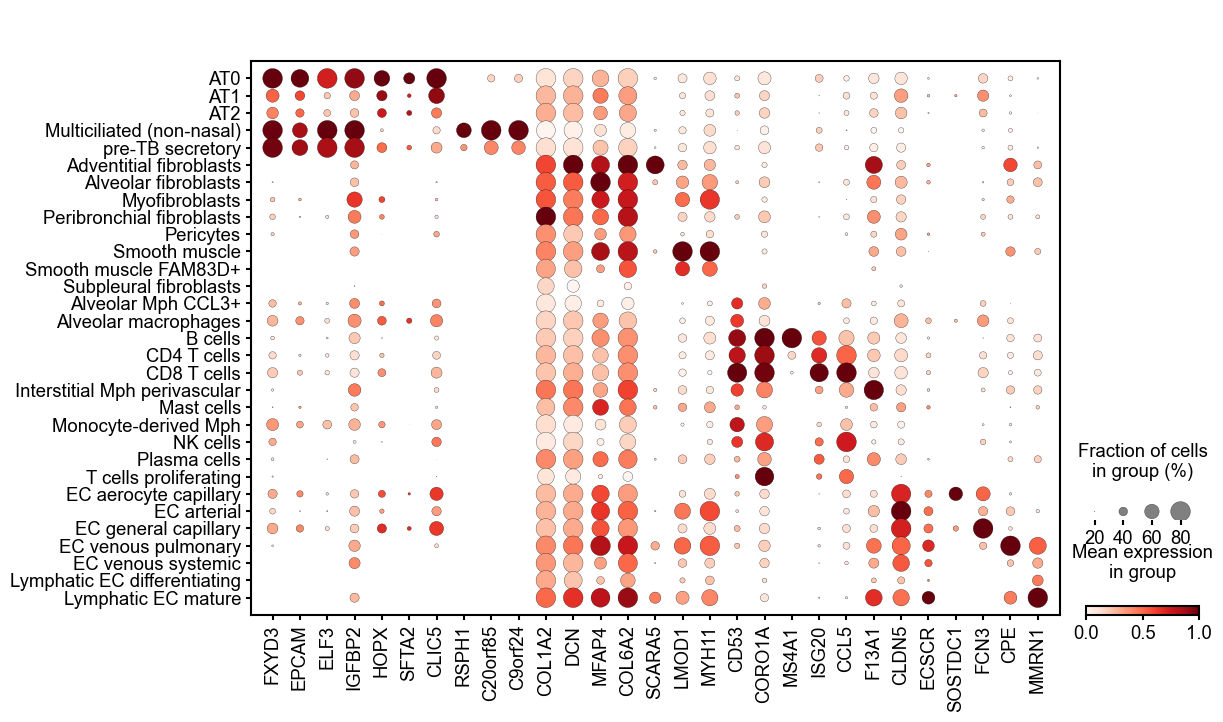

In [22]:
plt.rcParams.update({'font.size': 16}) 
fig, ax = plt.subplots(1,1, figsize = (12.5,7.5))
sc.pl.dotplot(adata_filtered, markers, groupby="cell_type_assigned", dendrogram=False, 
              categories_order= cell_type_order, use_raw=False,
              #var_group_labels=["Epithelial", "Immune","Endothelial","Mesenchymal"],
              #var_group_positions=[(0,9),(10,14),(15,15),(16,18)],

               # cmap = "viridis",

              standard_scale='var', vcenter=0.5, mean_only_expressed=False,
              ax = ax, 
              dot_min=0.2, dot_max = 0.8, show= False)


plt.tight_layout()
plt.savefig(os.path.join(save_dir,"dotplot_50p_with_legend.pdf"), transparent = True, bbox_inches = "tight")
plt.show()

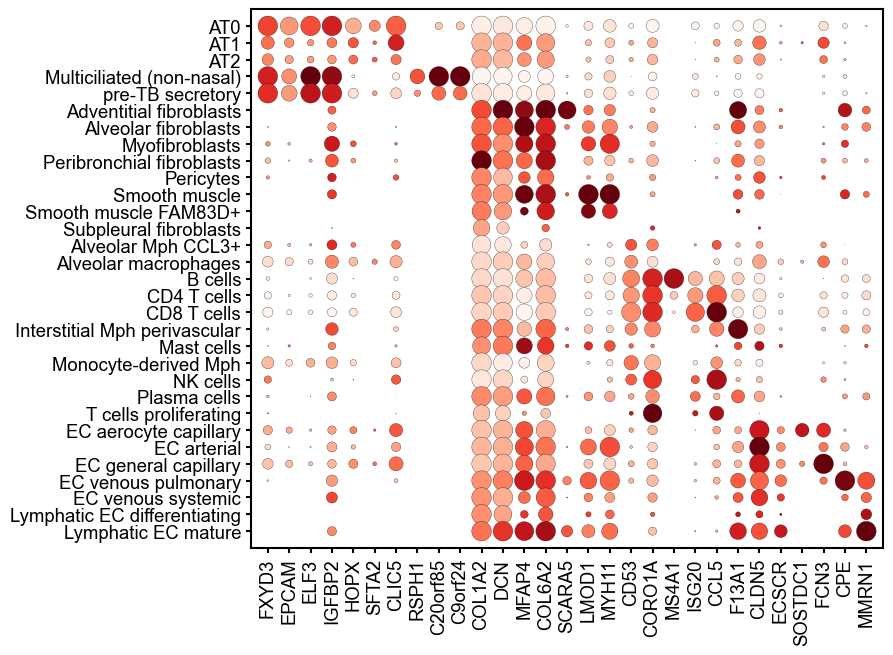

In [23]:
from scanpy.plotting import DotPlot
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16}) 

# Initialize DotPlot object
dp = DotPlot(
    adata_filtered,
    markers,
    groupby="cell_type_assigned",
    categories_order=cell_type_order,
    use_raw=False,
    standard_scale='var',
    figsize = (8.5, 7),
    vcenter=0.5,
    mean_only_expressed=True,
    cmap = "Reds"
)

# Set dot size scaling attributes
dp.dot_min = 0.2   # minimum fraction/size
dp.dot_max = 0.8   # maximum fraction/size
dp.dot_size_max = 80  # maximum marker size in points


dp.legend(show = False)

# Save figure
dp.savefig(os.path.join(save_dir,"dotplot_50p_fitered_no_legend.pdf"), transparent=True, bbox_inches="tight")

